# Consolidação de Bancos de Dados para Treinamento de YOLO

Este notebook executa o script de consolidação para juntar imagens de múltiplos bancos de dados do Roboflow em um único dataset padronizado, unificando classes para `lixo` (ID 0) e gerando anotações visuais para validação manual.

In [1]:
# Adiciona o diretório raiz ao path para importação do módulo src
import sys
import os
sys.path.append(os.path.abspath('..'))

## 1. Executar a Consolidação

Importa e executa a lógica de consolidação contida em `src/data/consolidate.py`.

In [3]:
from src.data.consolidate import run_consolidation
run_consolidation(base_dir='..')

Found 8 datasets to consolidate:
 - classificador-de-lixo
 - garbage-8uzha
 - garbage-byghu
 - garbage-classification-oaf5d
 - garbage-mvzg3
 - garbage-ylmfy
 - trash-lstse
 - wasteinsight-nopp5

Saved mapping JSON to ../data/metadata/mapping.json

Processing dt1 (classificador-de-lixo)...
 - Processed 23 images/labels for dt1

Processing dt2 (garbage-8uzha)...
 - Processed 3382 images/labels for dt2

Processing dt3 (garbage-byghu)...
 - Processed 33 images/labels for dt3

Processing dt4 (garbage-classification-oaf5d)...
 - Processed 1 images/labels for dt4

Processing dt5 (garbage-mvzg3)...
 - Processed 865 images/labels for dt5

Processing dt6 (garbage-ylmfy)...
 - Processed 515 images/labels for dt6

Processing dt7 (trash-lstse)...
 - Processed 159 images/labels for dt7

Processing dt8 (wasteinsight-nopp5)...
 - Processed 441 images/labels for dt8

Saved traceability CSV to ../data/metadata/traceability.csv
Saved unified data.yaml to ../data/processed/data.yaml

Dataset consolidatio

## 2. Estatísticas do Dataset Consolidado

Carrega o mapeamento (`mapping.json`) e a tabela de rastreabilidade (`traceability.csv`) para analisar o dataset gerado.

In [4]:
import pandas as pd
import json

# Carrega mapping
with open('../data/metadata/mapping.json', 'r', encoding='utf-8') as f:
    mapping = json.load(f)

# Exibe a tabela de mapeamento de datasets
df_mapping = pd.DataFrame.from_dict(mapping, orient='index')
display(df_mapping[['alias', 'original_folder', 'dataset_name', 'roboflow_url', 'classes']])

,alias,original_folder,dataset_name,roboflow_url,classes
dt1,dt1,classificador-de-lixo,classificador de lixo > 2024-07-18 8:17pm,https://universe.roboflow.com/lixo-bh-e-rio/cl...,"[domestico, entulho, lixeiras]"
dt2,dt2,garbage-8uzha,garbage > ver1.1,https://universe.roboflow.com/project-r1emy/ga...,"[black_bag, red_bag, white_bag, yellow_bag]"
dt3,dt3,garbage-byghu,garbage > 2022-04-17 2:39am,https://universe.roboflow.com/stella-wu/garbag...,"[bag, cardboard, furniture, glass, metal, pape..."
dt4,dt4,garbage-classification-oaf5d,garbage classification > 2023-11-15 5:14am,https://universe.roboflow.com/bsuir-wmujb/garb...,"[bag, plastic, wood]"
dt5,dt5,garbage-mvzg3,garbage > 2023-11-17 12:22am,https://universe.roboflow.com/bill-lhxqf/garba...,"[bag - v4 2023-05-12 11-25pm, object]"
dt6,dt6,garbage-ylmfy,garbage > 2022-02-12 5:02pm,https://universe.roboflow.com/new-workspace-ne...,"[cardboard, container_small, garbage_bag]"
dt7,dt7,trash-lstse,trash > 2025-09-16 5:23pm,https://universe.roboflow.com/label-zdxee/tras...,[trashbag]
dt8,dt8,wasteinsight-nopp5,WasteInsight > 2024-03-30 11:19am,https://universe.roboflow.com/volumeestimation...,[Plastic_Bag]


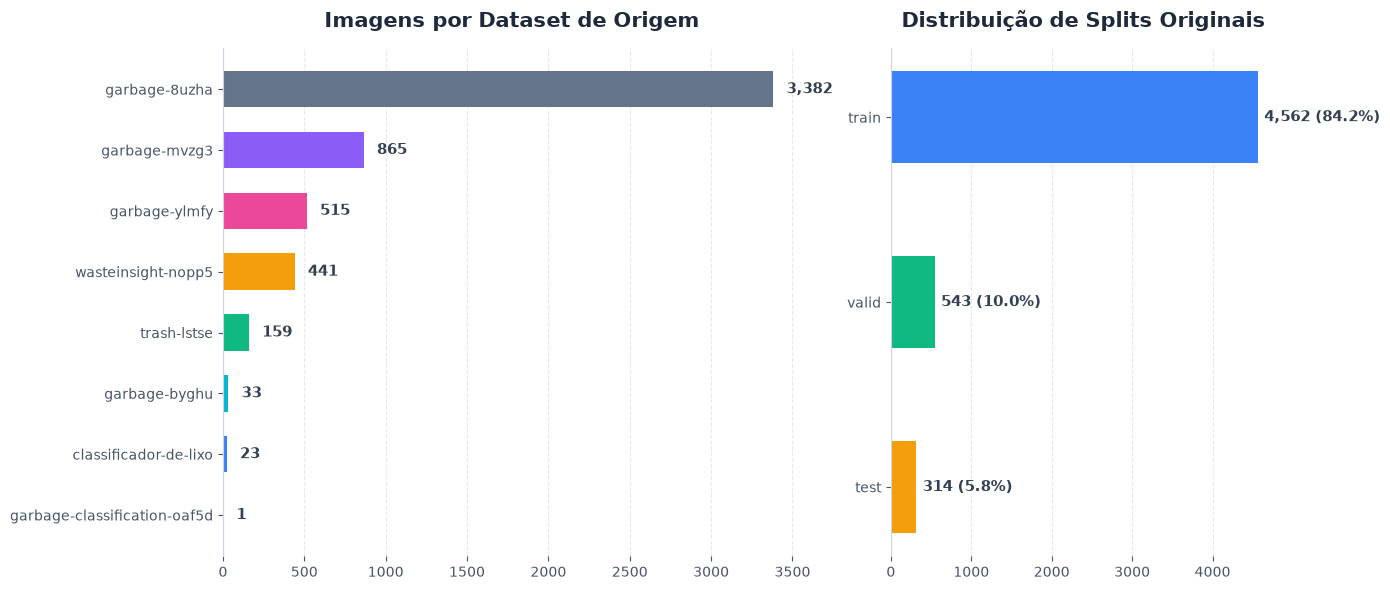

In [16]:
# Carrega a tabela de rastreabilidade
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

df_trace = pd.read_csv('../data/metadata/traceability.csv')

# 1. Resumo Executivo em HTML/CSS (Cards Estilizados)
total_imagens = len(df_trace)
num_datasets = df_trace['original_dataset'].nunique()
split_dist = df_trace['original_split'].value_counts()
dataset_dist = df_trace['original_dataset'].value_counts()

html_summary = f"""
<div style=\"font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; padding: 20px; background-color: #f8fafc; border-radius: 16px; border: 1px solid #e2e8f0; max-width: 800px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.05), 0 2px 4px -1px rgba(0, 0, 0, 0.03);\">
    <h3 style=\"margin-top: 0; color: #1e293b; font-size: 20px; font-weight: 700; border-bottom: 2px solid #e2e8f0; padding-bottom: 10px;\">📊 Resumo Executivo da Consolidação</h3>
    
    <div style=\"display: flex; gap: 20px; margin-bottom: 5px;\">
        <div style=\"flex: 1; background: linear-gradient(135deg, #3b82f6 0%, #1d4ed8 100%); padding: 20px; border-radius: 12px; color: white; box-shadow: 0 4px 12px rgba(29, 78, 216, 0.15);\">
            <div style=\"font-size: 14px; opacity: 0.85; font-weight: 600; text-transform: uppercase; letter-spacing: 0.05em;\">Total de Imagens</div>
            <div style=\"font-size: 32px; font-weight: 800; margin-top: 5px;\">{total_imagens:,}</div>
            <div style=\"font-size: 12px; opacity: 0.75; margin-top: 5px;\">Imagens</div>
        </div>
        
        <div style=\"flex: 1; background: linear-gradient(135deg, #10b981 0%, #047857 100%); padding: 20px; border-radius: 12px; color: white; box-shadow: 0 4px 12px rgba(4, 120, 87, 0.15);\">
            <div style=\"font-size: 14px; opacity: 0.85; font-weight: 600; text-transform: uppercase; letter-spacing: 0.05em;\">Datasets de Origem</div>
            <div style=\"font-size: 32px; font-weight: 800; margin-top: 5px;\">{num_datasets}</div>
            <div style=\"font-size: 12px; opacity: 0.75; margin-top: 5px;\">Fontes unificadas no pipeline</div>
        </div>
    </div>
</div>
"""
display(HTML(html_summary))

# 2. Gráficos Modernos e Limpos para Apresentação
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Arial', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#1e293b'
plt.rcParams['axes.labelcolor'] = '#1e293b'
plt.rcParams['xtick.color'] = '#475569'
plt.rcParams['ytick.color'] = '#475569'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.5, 1]})
fig.patch.set_facecolor('#ffffff')

colors_dataset = ['#4f46e5', '#3b82f6', '#06b6d4', '#10b981', '#f59e0b', '#ec4899', '#8b5cf6', '#64748b']
colors_split = ['#3b82f6', '#10b981', '#f59e0b']

# Gráfico 1: Dataset de Origem
dataset_dist_sorted = dataset_dist.sort_values(ascending=True)
bars1 = ax1.barh(dataset_dist_sorted.index, dataset_dist_sorted.values,
                 color=[colors_dataset[i % len(colors_dataset)] for i in range(len(dataset_dist_sorted))],
                 height=0.6, edgecolor='none')
ax1.set_title('Imagens por Dataset de Origem', fontsize=15, fontweight='bold', pad=15, color='#1e293b')
ax1.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cbd5e1')
ax1.set_axisbelow(True)

for spine in ['top', 'right', 'bottom']:
    ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color('#cbd5e1')

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + total_imagens*0.015, bar.get_y() + bar.get_height()/2, f'{int(width):,}',
             va='center', ha='left', fontsize=11, fontweight='bold', color='#334155')

# Gráfico 2: Divisão por Split Original
split_dist_sorted = split_dist.sort_values(ascending=True)
bars2 = ax2.barh(split_dist_sorted.index, split_dist_sorted.values,
                 color=colors_split[::-1],
                 height=0.5, edgecolor='none')
ax2.set_title('Distribuição de Splits Originais', fontsize=15, fontweight='bold', pad=15, color='#1e293b')
ax2.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cbd5e1')
ax2.set_axisbelow(True)

for spine in ['top', 'right', 'bottom']:
    ax2.spines[spine].set_visible(False)
ax2.spines['left'].set_color('#cbd5e1')

for bar in bars2:
    width = bar.get_width()
    percentage = (width / total_imagens) * 100
    ax2.text(width + total_imagens*0.015, bar.get_y() + bar.get_height()/2, f'{int(width):,} ({percentage:.1f}%)',
             va='center', ha='left', fontsize=11, fontweight='bold', color='#334155')

plt.tight_layout()
plt.show()


## 3. Visualização de Amostras Anotadas (QA)

Plota algumas imagens aleatórias com suas bounding boxes desenhadas da pasta `data/visual` para inspeção visual rápida.

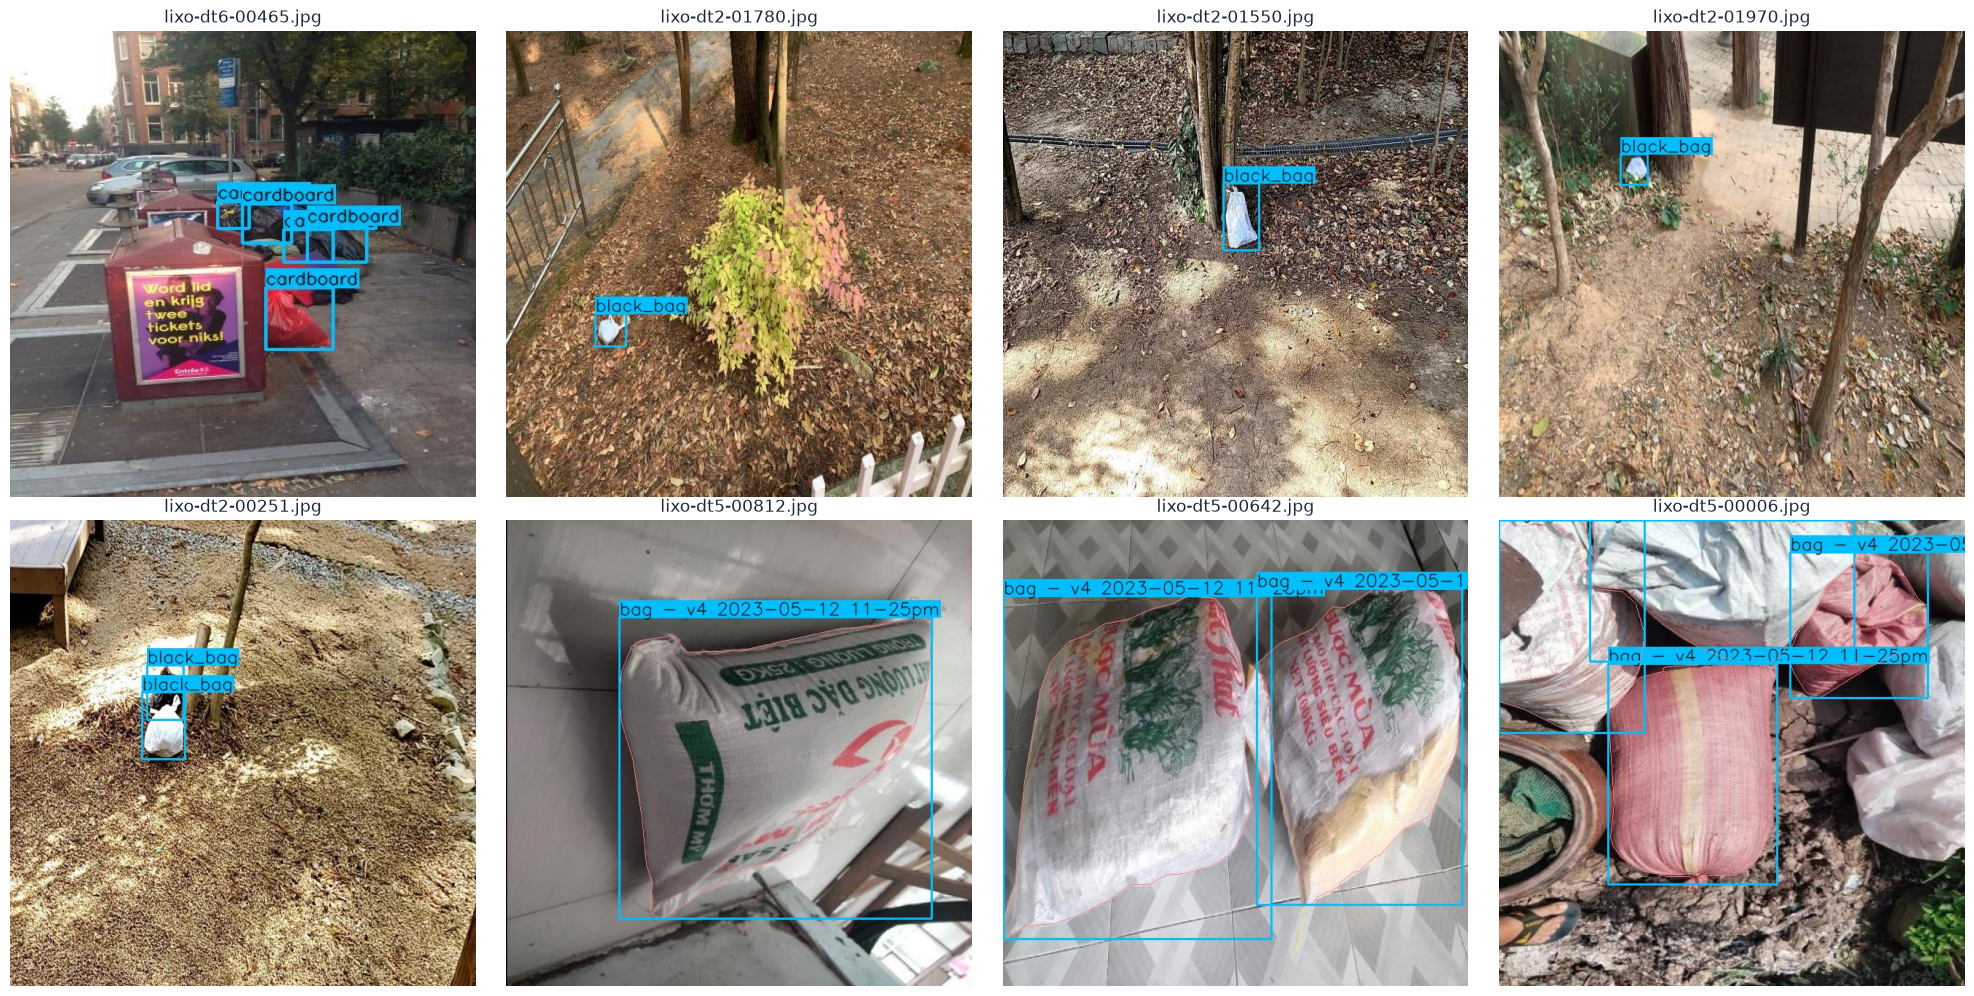

In [17]:
import cv2
import matplotlib.pyplot as plt
import random
import glob
import os  # Adicionado o import que faltava para o os.path.basename

visual_images = glob.glob('../data/visual/*.jpg') + glob.glob('../data/visual/*.png')

if visual_images:
    # 1. Altera o sorteio para selecionar até 8 imagens aleatórias
    samples = random.sample(visual_images, min(8, len(visual_images)))
    
    # 2. Altera a matriz para 2 linhas e 4 colunas (2 * 4 = 8 subplots)
    # Ajustamos o figsize para (20, 10) para acomodar a largura extra
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.ravel()
    
    for idx, img_path in enumerate(samples):
        img = cv2.imread(img_path)
        # OpenCV carrega em BGR, convertemos para RGB para exibir no Matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(os.path.basename(img_path))
        axes[idx].axis('off')
        
    # 3. Tratamento extra: caso o diretório tenha menos de 8 imagens (ex: 6),
    # este loop esconde os eixos dos quadrados que sobrarem em branco.
    for j in range(len(samples), len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma imagem encontrada na pasta data/visual/")